Fluids Homework 2

In [23]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import Fluids_Functions as ff
import scipy.io as sio

Control Volume Analysis

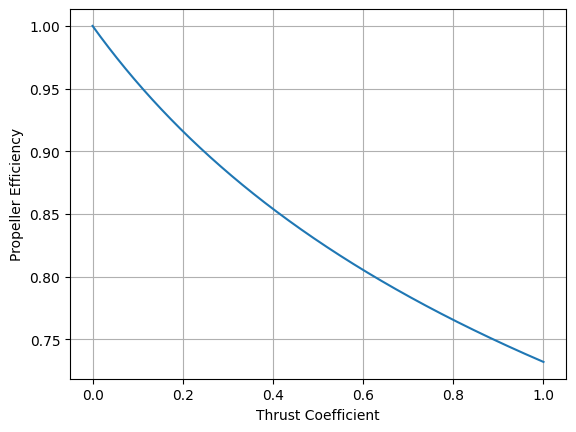

In [24]:
# Derive the expression for propeller efficiency. Plot the propeller efficiencies as a function of thrust coefficient. 
# Comment on the trend and what are the expected propeller efficiencies for various types of propellers.

# Constants
Ct = np.linspace(0, 1, 1000)
prop_eff = 2/(1+np.sqrt(1+2*Ct))

plt.plot(Ct, prop_eff)
plt.xlabel('Thrust Coefficient')
plt.ylabel('Propeller Efficiency')
plt.grid(True)
plt.show()

# From this plot, we can see that a lower coefficient of thrust results in much better efficiency ratios.
# Most aircrafts have a prop efficiency between .85 and .9 when cruising, which makes sense as their thrust coefficient can be low during this point.

Isentropic Flow

Parts 1-3: Thermodynamic Property Ratios

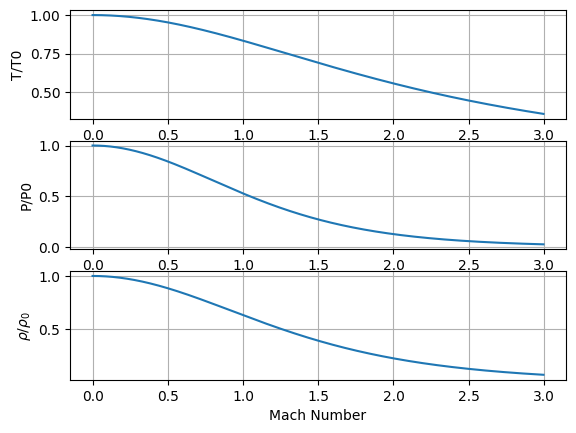

In [25]:
# Parts 1, 2, and 3

def isentropic_flow(gamma, P0, T0, M, R=287.05287):
    T = T0/(1+((gamma-1)*M**2)/2)
    P = P0 * (1+((gamma-1)*M**2)/2)**-(gamma/(gamma-1))
    rho0 = P0/(R*T0)
    rho = rho0 * (1+((gamma-1)*M**2)/2)**-(1/(gamma-1))
    return T, P, rho, rho0

P0_mach = 101325
T0_mach = 288.15
gamma_mach = 1.4

T_mach = np.zeros(1001)
P_mach = np.zeros(1001)
rho_mach = np.zeros(1001)
rho0_mach = np.zeros(1001)
rho_ratio_mach = np.zeros(1001)
M_mach = np.zeros(1001)

for i in range(0, 1001):
    M_mach[i] = i*(3/1001)
    T_mach[i], P_mach[i], rho_mach[i], rho0_mach[i] = isentropic_flow(gamma_mach, P0_mach, T0_mach, M_mach[i])
    rho_ratio_mach[i] = rho_mach[i]/rho0_mach[i]

fig, axs = plt.subplots(3, 1)

axs[0].plot(M_mach, T_mach/T0_mach)
axs[0].set_xlabel('Mach Number')
axs[0].set_ylabel('T/T0')
axs[0].grid(True)

axs[1].plot(M_mach, P_mach/P0_mach)
axs[1].set_xlabel('Mach Number')
axs[1].set_ylabel('P/P0')
axs[1].grid(True)

axs[2].plot(M_mach, rho_ratio_mach)
axs[2].set_xlabel('Mach Number')
axs[2].set_ylabel(r'$\rho$/$\rho_0$')
axs[2].grid(True) 

Parts 4 and 4a: Thermodynamic properties along the length of the wind tunnel

1.226879763484479 0.05009243273837887 101530.34720918181 1.2284193399973855


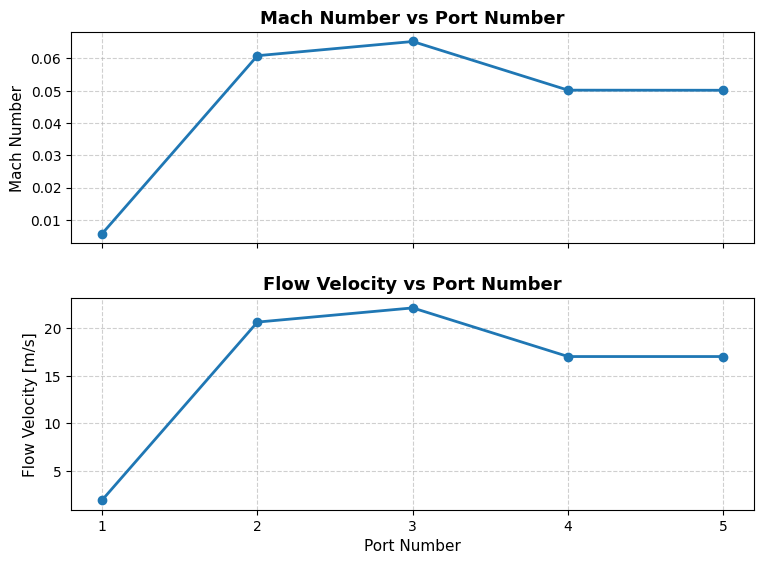

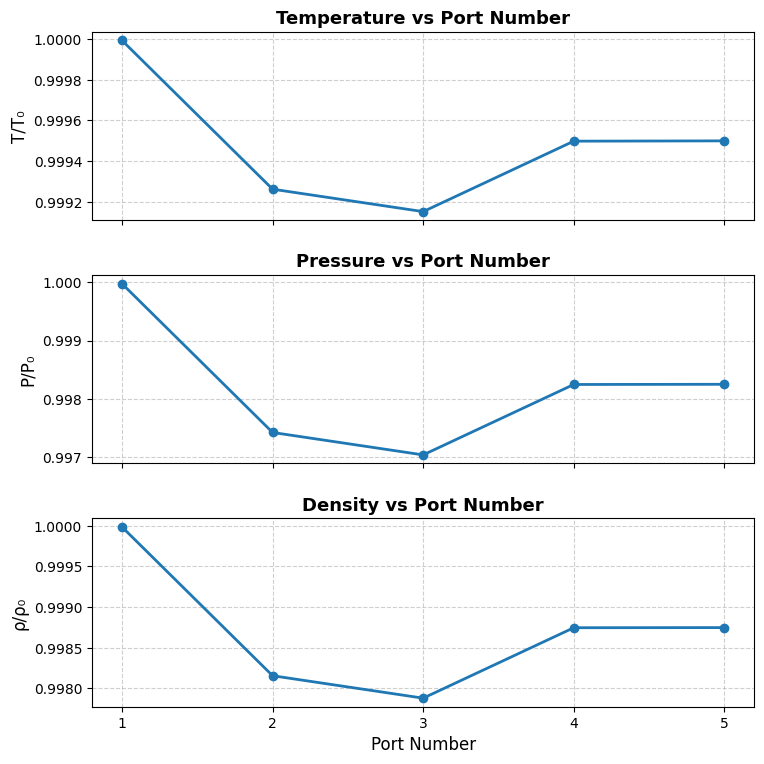

[101325.         101065.65244537 101026.54819794 101149.32183746
 101352.32425648] [101327.30733292 101327.30733292 101327.30733292 101327.30733292
 101530.34720918] [288.14812527 287.9372087  287.90537332 288.00529574 288.34145335] [288.15       288.15       288.15       288.15       288.48590552]


In [26]:
# Part 4

# constants
d = sio.loadmat(str('Fluids_Lab1_Data/S02G2D2RPM500.mat'), squeeze_me=True, struct_as_record=False, simplify_cells=True)
P = d.get("P")
l, w = np.shape(P) # type: ignore
P_avg = np.zeros(w)
for i in range(0,w):
    P_avg[i] = np.average(P[:,i]) + 101325 # type: ignore
Pt, Ps1, Ps2, Ps3, Ps4, Ps5 = P_avg
Ps = np.array([Ps1, Ps2, Ps3, Ps4, Ps5])
T0 = 288.15
gamma = 1.4
port = np.linspace(1, 5, 5)
cv = 718
cp = 1004.5
R = cp - cv
rho0 = 1.225

# analysis

# Fix state 1
M1 = np.sqrt((2/(gamma-1))*((Pt/Ps1)**((gamma-1)/gamma) - 1))
T1 = T0/(1+((gamma-1)*M1**2)/2)
rho1 = Ps1/(R*T1)
P01 = Ps1*(1+((gamma-1)*M1**2)/2)**(gamma/(gamma-1))
T01 = T1*(1+((gamma-1)*M1**2)/2)
rho01 = rho1*(1+((gamma-1)*M1**2)/2)**(1/(gamma-1))
U1 = M1*np.sqrt(gamma*R*T1)

# Fix state 2
M2 = np.sqrt((2/(gamma-1))*((Pt/Ps2)**((gamma-1)/gamma) - 1))
T2 = T0/(1+((gamma-1)*M2**2)/2)
rho2 = Ps2/(R*T2)
P02 = Ps2*(1+((gamma-1)*M2**2)/2)**(gamma/(gamma-1))
T02 = T2*(1+((gamma-1)*M2**2)/2)
rho02 = rho2*(1+((gamma-1)*M2**2)/2)**(1/(gamma-1))
U2 = M2*np.sqrt(gamma*R*T2)

# Fix state 3
M3 = np.sqrt((2/(gamma-1))*((Pt/Ps3)**((gamma-1)/gamma) - 1))
T3 = T0/(1+((gamma-1)*M3**2)/2)
rho3 = Ps3/(R*T3)
P03 = Ps3*(1+((gamma-1)*M3**2)/2)**(gamma/(gamma-1))
T03 = T3*(1+((gamma-1)*M3**2)/2)
rho03 = rho3*(1+((gamma-1)*M3**2)/2)**(1/(gamma-1))
U3 = M3*np.sqrt(gamma*R*T3)

# Fix state 4
M4 = np.sqrt((2/(gamma-1))*((Pt/Ps4)**((gamma-1)/gamma) - 1))
T4 = T0/(1+((gamma-1)*M4**2)/2)
rho4 = Ps4/(R*T4)
P04 = Ps4*(1+((gamma-1)*M4**2)/2)**(gamma/(gamma-1))
T04 = T4*(1+((gamma-1)*M4**2)/2)
rho04 = rho4*(1+((gamma-1)*M4**2)/2)**(1/(gamma-1))
U4 = M4*np.sqrt(gamma*R*T4)
    
# Fix state 5
U5 = U4
win = 10400/(rho04*U4*np.pi*(1.37/2)**2)
T05 = T04 + win/cp
T5 = T05 - (U5**2)/(2*cp)
M5 = U5/np.sqrt(gamma*R*T5)
rho5 = Ps5/(R*T5)
P05 = Ps5 + .5*rho5*U5**2
rho05 = P05/(R*T05)
print(rho5, M5, P05, rho05)

M = np.array([M1, M2, M3, M4, M5])
U = np.array([U1, U2, U3, U4, U5])
P = np.array([Ps1, Ps2, Ps3, Ps4, Ps5])
T = np.array([T1, T2, T3, T4, T5])
T0 = np.array([T01, T02, T03, T04, T05])
P0 = np.array([P01, P02, P03, P04, P05])
T_ratio = np.array([T1/T01, T2/T02, T3/T03, T4/T04, T5/T05])
P_ratio = np.array([Ps1/P01, Ps2/P02, Ps3/P03, Ps4/P04, Ps5/P05])
rho_ratio = np.array([rho1/rho01, rho2/rho02, rho3/rho03, rho4/rho04, rho5/rho05])

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Mach number plot
axs[0].plot(port, M, marker='o', linewidth=2)
axs[0].set_title("Mach Number vs Port Number", fontsize=13, fontweight='bold')
axs[0].set_ylabel("Mach Number", fontsize=11)
axs[0].grid(True, linestyle='--', alpha=0.6)

# Velocity plot
axs[1].plot(port, U, marker='o', linewidth=2)
axs[1].set_title("Flow Velocity vs Port Number", fontsize=13, fontweight='bold')
axs[1].set_xlabel("Port Number", fontsize=11)
axs[1].set_ylabel("Flow Velocity [m/s]", fontsize=11)
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.xticks(port)
plt.tight_layout(pad=2.0)
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

# Temperature ratio
axs[0].plot(port, T_ratio, marker='o', linewidth=2)
axs[0].set_title("Temperature vs Port Number", fontsize=13, fontweight='bold')
axs[0].set_ylabel("T/T₀", fontsize=12)
axs[0].grid(True, linestyle='--', alpha=0.6)

# Pressure ratio
axs[1].plot(port, P_ratio, marker='o', linewidth=2)
axs[1].set_title("Pressure vs Port Number", fontsize=13, fontweight='bold')
axs[1].set_ylabel("P/P₀", fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.6)

# Density ratio
axs[2].plot(port, rho_ratio, marker='o', linewidth=2)
axs[2].set_title("Density vs Port Number", fontsize=13, fontweight='bold')
axs[2].set_xlabel("Port Number", fontsize=12)
axs[2].set_ylabel("ρ/ρ₀", fontsize=12)
axs[2].grid(True, linestyle='--', alpha=0.6)

plt.xticks(port)
plt.tight_layout(pad=2.0)
plt.show()
print(P, P0, T, T0)

Parts 4b, c, and d: Isentropic Analysis

Change in entropy across the wind tunnel test section: -0.0001934970660315699% J/kg.K

Change in entropy across the wind tunnel fan: 0.5973439535596474 J/kg.K


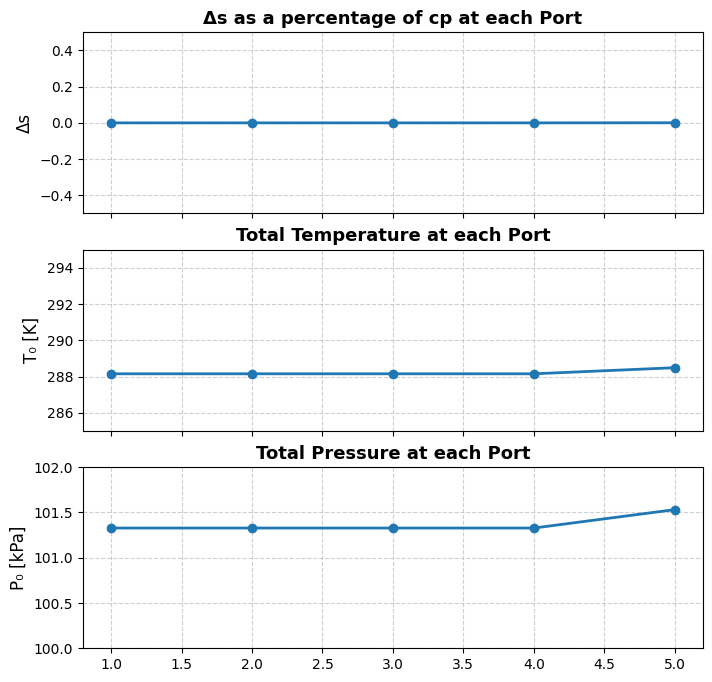

In [27]:
# Change in entropy across the wind tunnel's test section
dels_tstsect = cp * np.log(T3/T2) - R * np.log(Ps3/Ps2)
print(f"Change in entropy across the wind tunnel test section: {dels_tstsect}% J/kg.K\n")
# The reason the entropy change is calculated as negative is because of our assumption that the system is adiabatic.
# We assumed T0 to be constant from ports 1 to 4 and used it to calculate T-static, but then used physical data for static pressure
# The physical data for static pressure increases from port 2 to 3, so realistically, the static temperature must increase to keep entropy from
# decreasing. But our adiabatic assumption gives us a decrease in temperature from ports 2 to 3, therefore the calculated entropy change is negative

# Change in entropy across the wind tunnel's fan
dels_fan = cp * np.log(T5/T4) - R * np.log(Ps5/Ps4)
print(f"Change in entropy across the wind tunnel fan: {dels_fan} J/kg.K")

dels_12 = cp * np.log(T2/T1) - R * np.log(Ps2/Ps1)
dels_34 = cp * np.log(T4/T3) - R * np.log(Ps4/Ps3)

dels = np.array([0, dels_12, dels_tstsect, dels_34, dels_fan])/cp

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

# Delta s across the tunnel
axs[0].plot(port, dels, marker='o', linewidth=2)
axs[0].set_title("\u0394s as a percentage of cp at each Port", fontsize=13, fontweight='bold')
axs[0].set_ylabel("\u0394s", fontsize=12)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].set_ylim(-0.5, .5)

# Total Temperature across the tunnel
axs[1].plot(port, T0, marker='o', linewidth=2)
axs[1].set_title("Total Temperature at each Port", fontsize=13, fontweight='bold')
axs[1].set_ylabel("T₀ [K]", fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].set_ylim(285, 295)

# Total Pressure across the tunnel
axs[2].plot(port, P0/1000, marker='o', linewidth=2)
axs[2].set_title("Total Pressure at each Port", fontsize=13, fontweight='bold')
axs[2].set_ylabel("P₀ [kPa]", fontsize=12)
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].set_ylim(100, 102)

plt.show()

# To determine whether the wind tunnel system can be treated as isentropic or not, we must first look to see whether the system has a negligable change in entropy,
# In the first graph below, its clear that while the entropy does change from port to port, the total change is extremely close to zero, meaning we can likely disregard it.
# We can also check change in T0 to see if the system is adiabatic, in the graph below, it is evidently close to constant, not varying by more than a Kelvin
# Finally, to check if the system is reversible for sure, we can look for variations in pressure, which doesn't vary by more than half a kPa.
# So yes, I would say the assumption that the lowspeed wind tunnel is isentropic is a safe assumption to make.


Part 5: Density Ratio compared to Mach graph

(0.9, 1.05)

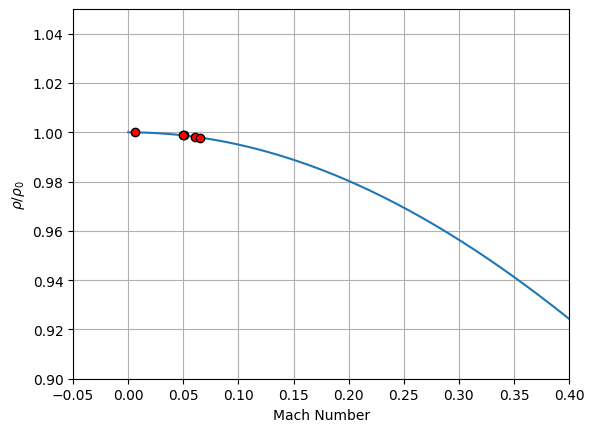

In [28]:
plt.plot(M_mach, rho_ratio_mach)
plt.xlabel('Mach Number')
plt.ylabel(r'$\rho$/$\rho_0$')
plt.grid(True)
plt.plot(M, rho_ratio , marker='o', linestyle='', markersize=6, markerfacecolor='red', markeredgecolor='black')
plt.xlim(-.05,.4)
plt.ylim(.9, 1.05)
# The flow is subsonic incompressible, as the values fall extremely close to the isentropic density ratio line and is well below .3 Mach

Isentropic Flow 2

Bernoulli's Analysis

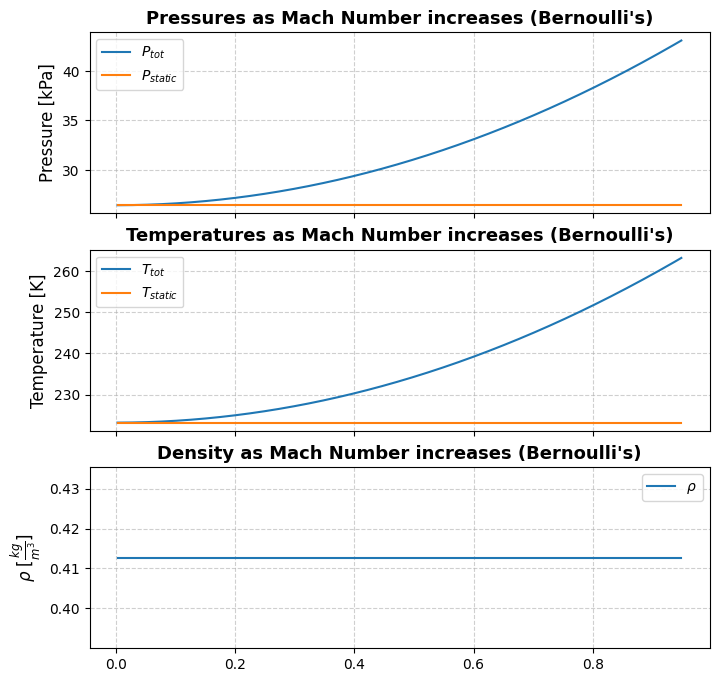

In [29]:
# constants
U = np.linspace(1,284,1000)
R_air = 287
T, P_inf, rho, _, a = ff.standardatmosphere(10000)
cp = 1005
gamma = 1.4

# Bernoullis Equation
def P_tot(P, U, rho):
    return P + (rho/2)*(U)**2

def T_tot(T, U, cp):
    return T + U**2/(2*cp)

def Mach(U, a):
    return U/a

P_inf_graph = P_inf*np.ones(1000)
T_s_graph = T*np.ones(1000)
rho_graph = rho*np.ones(1000)

fig, axs = plt.subplots(3,1, figsize=(8, 8), sharex=True)

# Total and Static Pressure
axs[0].plot(Mach(U,a),P_tot(P_inf, U, rho)/1000, label=r"$P_{tot}$")
axs[0].plot(Mach(U,a),P_inf_graph/1000, label=r"$P_{static}$")
axs[0].set_title("Pressures as Mach Number increases (Bernoulli's)", fontsize=13, fontweight='bold')
axs[0].set_ylabel('Pressure [kPa]', fontsize=12)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# Total and Static Temperature
axs[1].plot(Mach(U,a), T_tot(T, U, cp), label=r"$T_{tot}$")
axs[1].plot(Mach(U,a), T_s_graph, label=r"$T_{static}$")
axs[1].set_title("Temperatures as Mach Number increases (Bernoulli's)", fontsize=13, fontweight='bold')
axs[1].set_ylabel("Temperature [K]", fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

# Density
axs[2].plot(Mach(U,a), rho_graph, label=r"$\rho$")
axs[2].set_title("Density as Mach Number increases (Bernoulli's)", fontsize=13, fontweight='bold')
axs[2].set_ylabel(r"$\rho$ [$\frac{kg}{m^3}$]", fontsize=12)
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()

plt.show()

Isentropic Analysis

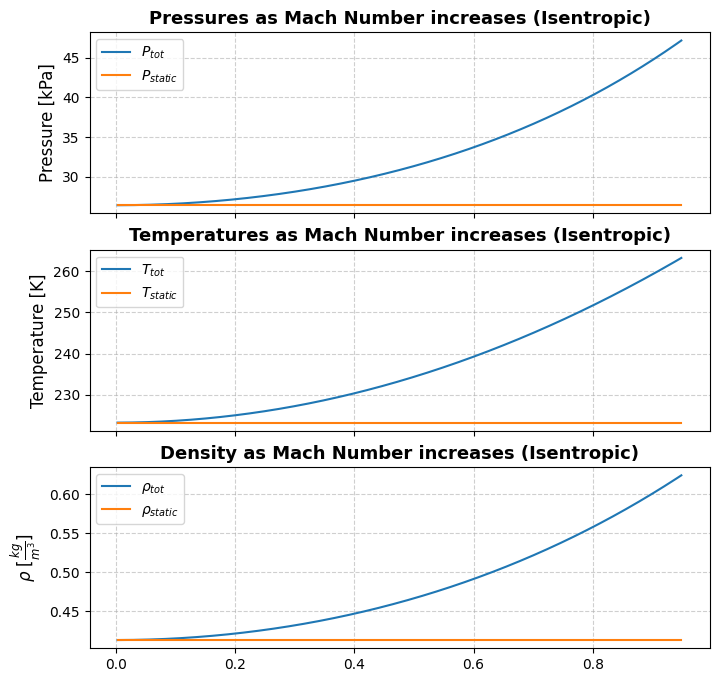

In [30]:
def iseP0(gamma,M,P):
    return ((1+((gamma-1)/2)*M**2)**(gamma/(gamma-1)))*P
def iseT0(gamma,M,T):
    return (1+((gamma-1)/2)*M**2)*T
def iseRho0(gamma,M,rho):
    return ((1+((gamma-1)/2)*M**2)**(1/(gamma-1)))*rho

rho0_ise = iseRho0(gamma, Mach(U,a), rho)
fig, axs = plt.subplots(3,1, figsize=(8, 8), sharex=True)

# Total and Static Pressure
axs[0].plot(Mach(U,a),iseP0(gamma, Mach(U,a), P_inf)/1000, label=r"$P_{tot}$")
axs[0].plot(Mach(U,a),P_inf_graph/1000, label=r"$P_{static}$")
axs[0].set_title('Pressures as Mach Number increases (Isentropic)', fontsize=13, fontweight='bold')
axs[0].set_ylabel('Pressure [kPa]', fontsize=12)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# Total and Static Temperature
axs[1].plot(Mach(U,a), iseT0(gamma, Mach(U,a),T), label=r"$T_{tot}$")
axs[1].plot(Mach(U,a), T_s_graph, label=r"$T_{static}$")
axs[1].set_title("Temperatures as Mach Number increases (Isentropic)", fontsize=13, fontweight='bold')
axs[1].set_ylabel("Temperature [K]", fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()


# Density
axs[2].plot(Mach(U,a), iseRho0(gamma, Mach(U,a),rho), label=r"$\rho_{tot}$")
axs[2].plot(Mach(U,a), rho_graph, label=r"$\rho_{static}$")
axs[2].set_title("Density as Mach Number increases (Isentropic)", fontsize=13, fontweight='bold')
axs[2].set_ylabel(r"$\rho$ [$\frac{kg}{m^3}$]", fontsize=12)
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()
plt.show()

What speed does Bernoulli's break

In [31]:
ratio = rho0_ise / rho
i = np.argmin(np.abs(ratio - 1.05))
print(f"Index: {i}")
print(f"Mach number: {M_mach[i]:.3f}")

Index: 328
Mach number: 0.983


Conservation of Mass

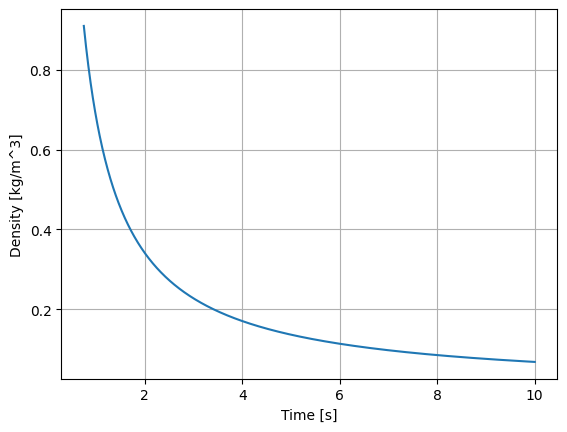

Time: 4.166666666666667 s


In [32]:
# Constants
rho0 = .91
t = np.linspace(.75, 10, 1001)
rho = (.75/t)*rho0

plt.plot(t,rho)
plt.xlabel('Time [s]')
plt.ylabel('Density [kg/m^3]')
plt.grid(True)
plt.show()

t = .75/.003
print(f"Time: {t/60} s")